# Final Ablation v2 (Fresh Fetch, LoRA vs No-LoRA Side-by-Side)

This notebook fetches the new final-ablation runs (including model and probe-dtype in the run ID), keeps unfinished runs in analysis, and provides a single function to compare LoRA vs no-LoRA by layer for R@0.1, AUC, F1, or final loss.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

api = wandb.Api()
ENTITY = "ethz-lsai-25"
PROJECT = "hallucination-probes"
RUN_PATH = f"{ENTITY}/{PROJECT}"

print("W&B path:", RUN_PATH)

W&B path: ethz-lsai-25/hallucination-probes


In [2]:
LAYERS = [10, 20, 26, 30]
SEEDS = [42, 43, 44]
TRAIN_MODELS = ["apertus", "llama"]
TEST_MODELS = ["apertus", "llama"]
METRIC_FAMILIES = ["all", "span", "span_max"]
METRICS = ["auc", "f1", "acc", "recall_at_0.1_fpr"]

FINAL_VARIANTS = ["no_lora_no_ln", "no_lora_ln", "lora_no_ln", "lora_ln"]
FINAL_DTYPE_TAGS = ["fp32", "bf16"]
BASELINE_VARIANTS = ["llama_baseline", "apertus_bf16_baseline"]

MODEL_DISPLAY_NAMES = {
    "apertus": "Apertus-8B-Instruct-2509",
    "llama": "Llama-3.1-8B-Instruct",
}

DTYPE_TAG_TO_FULL = {
    "fp32": "float32",
    "bf16": "bfloat16",
}

NORM_DISPLAY = {
    "none": "none",
    "layernorm": "layernorm",
}

FINAL_VARIANT_META = {
    "no_lora_no_ln": {"normalize_before_head": "none", "lora_layers": "none"},
    "no_lora_ln": {"normalize_before_head": "layernorm", "lora_layers": "none"},
    "lora_no_ln": {"normalize_before_head": "none", "lora_layers": "all"},
    "lora_ln": {"normalize_before_head": "layernorm", "lora_layers": "all"},
}

FINAL_PATTERN = re.compile(
    r"^(apertus|llama)_seed_ablation_(no_lora_no_ln|no_lora_ln|lora_no_ln|lora_ln)_(fp32|bf16)_layer(10|20|26|30)_seed(42|43|44)$"
)

BASELINE_PATTERN = re.compile(
    r"^(apertus|llama)_no_lora_long_form_layer(10|20|26|30)_seed(42|43|44)$"
)

LOSS_KEYS = ["train/loss", "train/lm_loss", "train/kl_loss"]

In [5]:
def _safe_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def _cfg_get(cfg, dotted_key, *, nested_parent=None, nested_child=None):
    v = cfg.get(dotted_key)
    if v is not None:
        return v
    if nested_parent and nested_child:
        parent = cfg.get(nested_parent)
        if isinstance(parent, dict):
            return parent.get(nested_child)
    return None


def _canon_dtype(v):
    if v is None:
        return None
    k = str(v).strip().lower()
    if k in {"fp32", "float32", "torch.float32"}:
        return "float32"
    if k in {"fp16", "float16", "torch.float16"}:
        return "float16"
    if k in {"bf16", "bfloat16", "torch.bfloat16"}:
        return "bfloat16"
    if k in {"auto", "default", "model", ""}:
        return "auto"
    return k


def _canon_norm(v):
    if v is None:
        return None
    return str(v).strip().lower()


def _collect_text_candidates(run):
    cfg = run.config or {}
    vals = []
    if isinstance(run.name, str):
        vals.append(run.name)
    if isinstance(cfg.get("probe_config"), dict):
        nested = cfg["probe_config"].get("probe_id")
        if isinstance(nested, str):
            vals.append(nested)
    for k in ["probe_config.probe_id", "probe_config/probe_id", "probe_id"]:
        v = cfg.get(k)
        if isinstance(v, str):
            vals.append(v)
    return [v.strip() for v in vals if isinstance(v, str) and v.strip()]


def _extract_selected_id(run):
    for text in _collect_text_candidates(run):
        if FINAL_PATTERN.match(text) or BASELINE_PATTERN.match(text):
            return text
    return None

In [12]:
rows = []
for run in api.runs(RUN_PATH):
    selected_id = _extract_selected_id(run)
    if not selected_id:
        continue

    m_final = FINAL_PATTERN.match(selected_id)
    m_base = BASELINE_PATTERN.match(selected_id)
    if not (m_final or m_base):
        continue

    cfg = run.config or {}
    summary = run.summary._json_dict

    if m_final:
        train_model, variant, dtype_tag, layer, seed = m_final.groups()
        run_kind = "final_ablation"
        baseline_model = None
        expected_probe_dtype = DTYPE_TAG_TO_FULL[dtype_tag]
        expected_norm = _canon_norm(FINAL_VARIANT_META[variant]["normalize_before_head"])
    else:
        baseline_model, layer, seed = m_base.groups()
        train_model = baseline_model
        variant = "llama_baseline" if baseline_model == "llama" else "apertus_bf16_baseline"
        dtype_tag = "bf16"
        run_kind = "baseline"
        expected_probe_dtype = "bfloat16"
        expected_norm = None

    actual_probe_dtype = _canon_dtype(
        _cfg_get(cfg, "probe_config.probe_dtype", nested_parent="probe_config", nested_child="probe_dtype")
        or _cfg_get(cfg, "probe_config/probe_dtype")
        or _cfg_get(cfg, "probe_dtype")
    )
    actual_norm = _canon_norm(
        _cfg_get(cfg, "probe_config.normalize_before_head", nested_parent="probe_config", nested_child="normalize_before_head")
        or _cfg_get(cfg, "probe_config/normalize_before_head")
        or _cfg_get(cfg, "normalize_before_head")
    )
    actual_model_dtype = _canon_dtype(_cfg_get(cfg, "model_dtype"))

    row = {
        "run_id": run.id,
        "run_name": run.name,
        "selected_id": selected_id,
        "state": run.state,
        "created_at": pd.to_datetime(run.created_at, utc=True),
        "run_kind": run_kind,
        "train_model": train_model,
        "baseline_model": baseline_model,
        "variant": variant,
        "probe_dtype_tag": dtype_tag,
        "layer": int(layer),
        "seed": int(seed),
        "probe_dtype": actual_probe_dtype,
        "normalize_before_head": actual_norm,
        "model_dtype": actual_model_dtype,
        "probe_dtype_expected": expected_probe_dtype,
        "normalize_before_head_expected": expected_norm,
    }

    for test_model in TEST_MODELS:
        for family in METRIC_FAMILIES:
            for metric in METRICS:
                key = f"train/longfact_test_{test_model}/{family}_{metric}"
                row[key] = _safe_float(summary.get(key))

    for key in LOSS_KEYS:
        row[key] = _safe_float(summary.get(key))

    rows.append(row)

df_runs_raw = pd.DataFrame(rows)
if df_runs_raw.empty:
    raise ValueError("No runs matched final-ablation or baseline naming patterns.")

state_rank = {"finished": 0, "running": 1, "queued": 2, "failed": 3, "crashed": 4}
df_runs_raw["_state_rank"] = df_runs_raw["state"].map(state_rank).fillna(99)
df_runs_raw["_has_train_loss"] = df_runs_raw["train/loss"].notna().astype(int)

key_cols = ["run_kind", "train_model", "variant", "probe_dtype_tag", "layer", "seed"]
metric_value_cols = [
    f"train/longfact_test_{tm}/{fam}_{m}"
    for tm in TEST_MODELS
    for fam in METRIC_FAMILIES
    for m in METRICS
]
coalesce_cols = metric_value_cols + LOSS_KEYS + ["probe_dtype", "normalize_before_head", "model_dtype"]

df_runs_raw = df_runs_raw.sort_values(
    key_cols + ["_state_rank", "_has_train_loss", "created_at"],
    ascending=[True] * len(key_cols) + [True, False, False],
)

merged_rows = []
loss_backfilled_groups = 0
for _, group in df_runs_raw.groupby(key_cols, sort=False):
    base = group.iloc[0].copy()

    had_missing_loss = pd.isna(base.get("train/loss"))
    for col in coalesce_cols:
        if col not in group.columns:
            continue
        if pd.isna(base.get(col)):
            non_na = group[col].dropna()
            if not non_na.empty:
                base[col] = non_na.iloc[0]

    if had_missing_loss and pd.notna(base.get("train/loss")):
        loss_backfilled_groups += 1

    base["source_run_count"] = len(group)
    merged_rows.append(base)

df_runs = pd.DataFrame(merged_rows)
df_runs = (
    df_runs.drop(columns=["_state_rank", "_has_train_loss"], errors="ignore")
    .sort_values(["run_kind", "train_model", "variant", "probe_dtype_tag", "layer", "seed"])
    .reset_index(drop=True)
)

expected_final = len(TRAIN_MODELS) * len(FINAL_VARIANTS) * len(FINAL_DTYPE_TAGS) * len(LAYERS) * len(SEEDS)
found_final = len(df_runs[df_runs["run_kind"] == "final_ablation"])

expected_baseline = len(TRAIN_MODELS) * len(LAYERS) * len(SEEDS)
found_baseline = len(df_runs[df_runs["run_kind"] == "baseline"])

print(f"Expected final-ablation combinations: {expected_final}")
print(f"Found final-ablation rows: {found_final}")
print(f"Expected baseline combinations: {expected_baseline}")
print(f"Found baseline rows: {found_baseline}")
print(f"Loss backfilled from matching runs: {loss_backfilled_groups}")
print(f"Rows with train/loss available: {df_runs['train/loss'].notna().sum()}/{len(df_runs)}")
display(df_runs.groupby(["run_kind", "train_model", "variant", "probe_dtype_tag", "state"]).size().rename("n").reset_index())

Expected final-ablation combinations: 192
Found final-ablation rows: 192
Expected baseline combinations: 24
Found baseline rows: 24
Loss backfilled from matching runs: 16
Rows with train/loss available: 216/216


,run_kind,train_model,variant,probe_dtype_tag,state,n
0,baseline,apertus,apertus_bf16_baseline,bf16,finished,12
1,baseline,llama,llama_baseline,bf16,finished,12
2,final_ablation,apertus,lora_ln,bf16,finished,12
3,final_ablation,apertus,lora_ln,fp32,finished,12
4,final_ablation,apertus,lora_no_ln,bf16,finished,12
5,final_ablation,apertus,lora_no_ln,fp32,finished,12
6,final_ablation,apertus,no_lora_ln,bf16,finished,12
7,final_ablation,apertus,no_lora_ln,fp32,finished,12
8,final_ablation,apertus,no_lora_no_ln,bf16,finished,12
9,final_ablation,apertus,no_lora_no_ln,fp32,finished,12


In [13]:
metric_columns = [
    f"train/longfact_test_{tm}/{fam}_{m}"
    for tm in TEST_MODELS
    for fam in METRIC_FAMILIES
    for m in METRICS
]

df_metrics_long = df_runs.melt(
    id_vars=[
        "run_id", "run_name", "selected_id", "state", "created_at", "run_kind",
        "train_model", "baseline_model", "variant", "probe_dtype_tag", "layer", "seed",
        "probe_dtype", "normalize_before_head", "model_dtype",
        "probe_dtype_expected", "normalize_before_head_expected",
    ],
    value_vars=metric_columns,
    var_name="metric_key",
    value_name="value",
)

parts = df_metrics_long["metric_key"].str.extract(
    r"train/longfact_test_(apertus|llama)/(all|span|span_max)_(auc|f1|acc|recall_at_0\.1_fpr)"
)
parts.columns = ["test_model", "metric_family", "metric"]

df_metrics_long = pd.concat([df_metrics_long, parts], axis=1)
df_metrics_long = df_metrics_long.dropna(subset=["value", "test_model", "metric_family", "metric"])
df_metrics_long["value"] = pd.to_numeric(df_metrics_long["value"], errors="coerce")
df_metrics_long = df_metrics_long.dropna(subset=["value"]).reset_index(drop=True)

print("Metric rows:", len(df_metrics_long))
display(df_metrics_long.head(5))

Metric rows: 3888


,run_id,run_name,selected_id,state,created_at,run_kind,train_model,baseline_model,variant,probe_dtype_tag,...,probe_dtype,normalize_before_head,model_dtype,probe_dtype_expected,normalize_before_head_expected,metric_key,value,test_model,metric_family,metric
0,2msk68xv,apertus_no_lora_long_form_layer10_seed42,apertus_no_lora_long_form_layer10_seed42,finished,2026-03-02 14:54:28+00:00,baseline,apertus,apertus,apertus_bf16_baseline,bf16,...,None,None,None,bfloat16,None,train/longfact_test_apertus/all_auc,0.834979,apertus,all,auc
1,ennpfi5c,apertus_no_lora_long_form_layer10_seed43,apertus_no_lora_long_form_layer10_seed43,finished,2026-03-02 14:55:28+00:00,baseline,apertus,apertus,apertus_bf16_baseline,bf16,...,None,None,None,bfloat16,None,train/longfact_test_apertus/all_auc,0.830068,apertus,all,auc
2,ckfvtpqq,apertus_no_lora_long_form_layer10_seed44,apertus_no_lora_long_form_layer10_seed44,finished,2026-03-02 14:55:28+00:00,baseline,apertus,apertus,apertus_bf16_baseline,bf16,...,None,None,None,bfloat16,None,train/longfact_test_apertus/all_auc,0.823364,apertus,all,auc
3,5w54hojz,apertus_no_lora_long_form_layer20_seed42,apertus_no_lora_long_form_layer20_seed42,finished,2026-03-02 14:56:24+00:00,baseline,apertus,apertus,apertus_bf16_baseline,bf16,...,None,None,None,bfloat16,None,train/longfact_test_apertus/all_auc,0.721613,apertus,all,auc
4,h3qhm4bp,apertus_no_lora_long_form_layer20_seed43,apertus_no_lora_long_form_layer20_seed43,finished,2026-03-02 14:56:24+00:00,baseline,apertus,apertus,apertus_bf16_baseline,bf16,...,None,None,None,bfloat16,None,train/longfact_test_apertus/all_auc,0.732504,apertus,all,auc


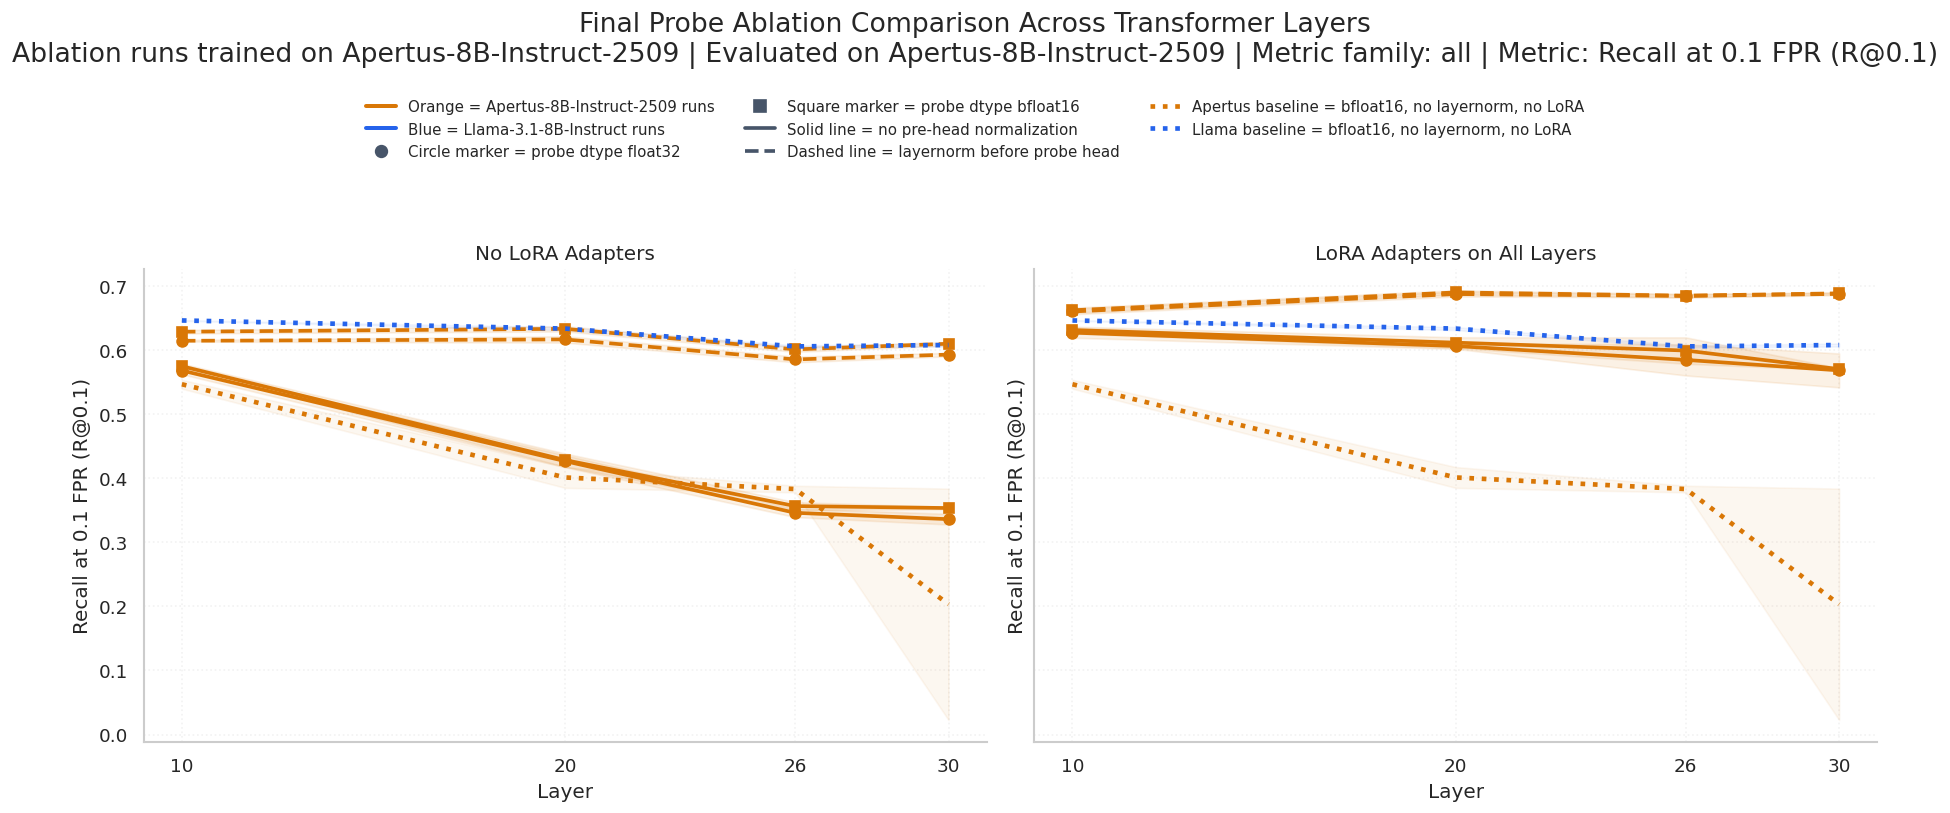

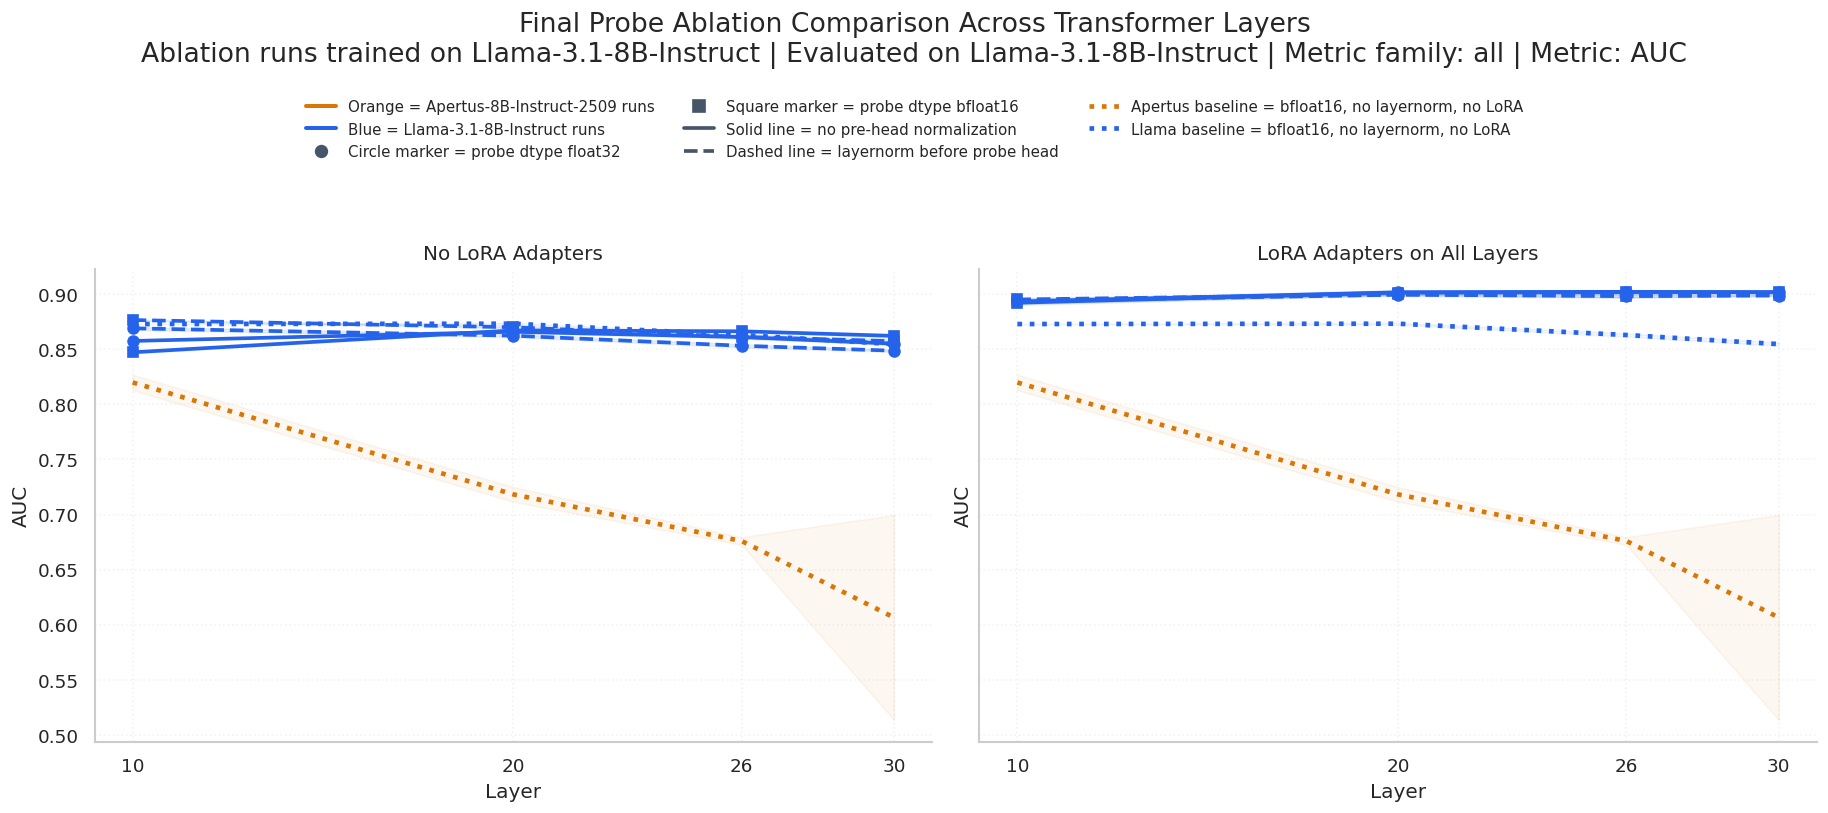

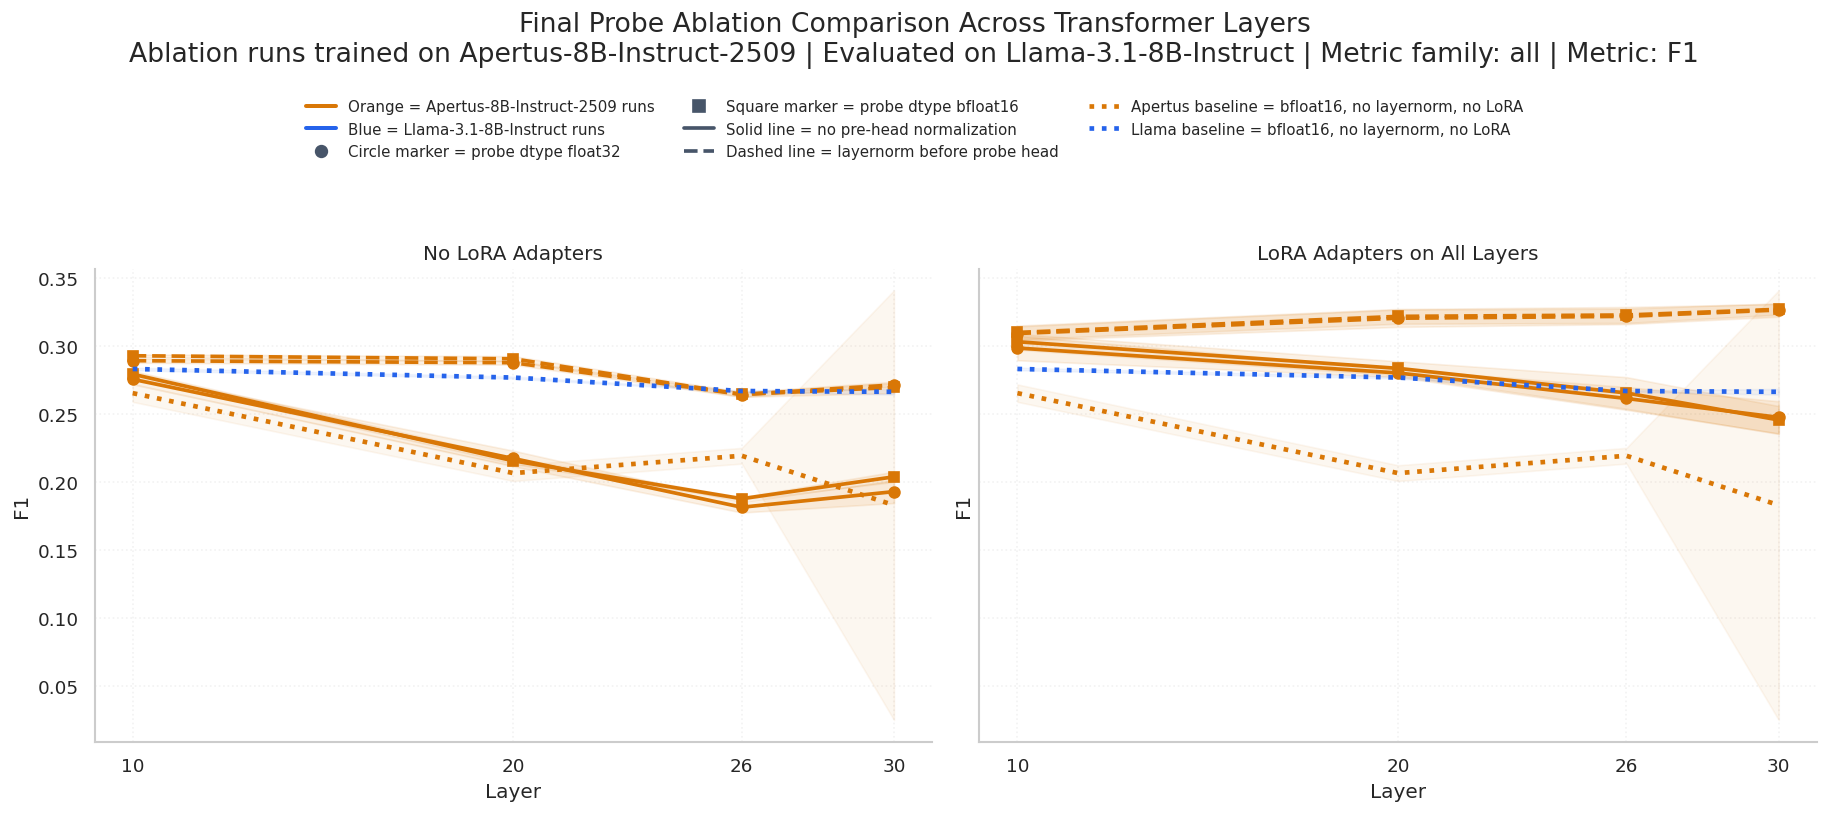

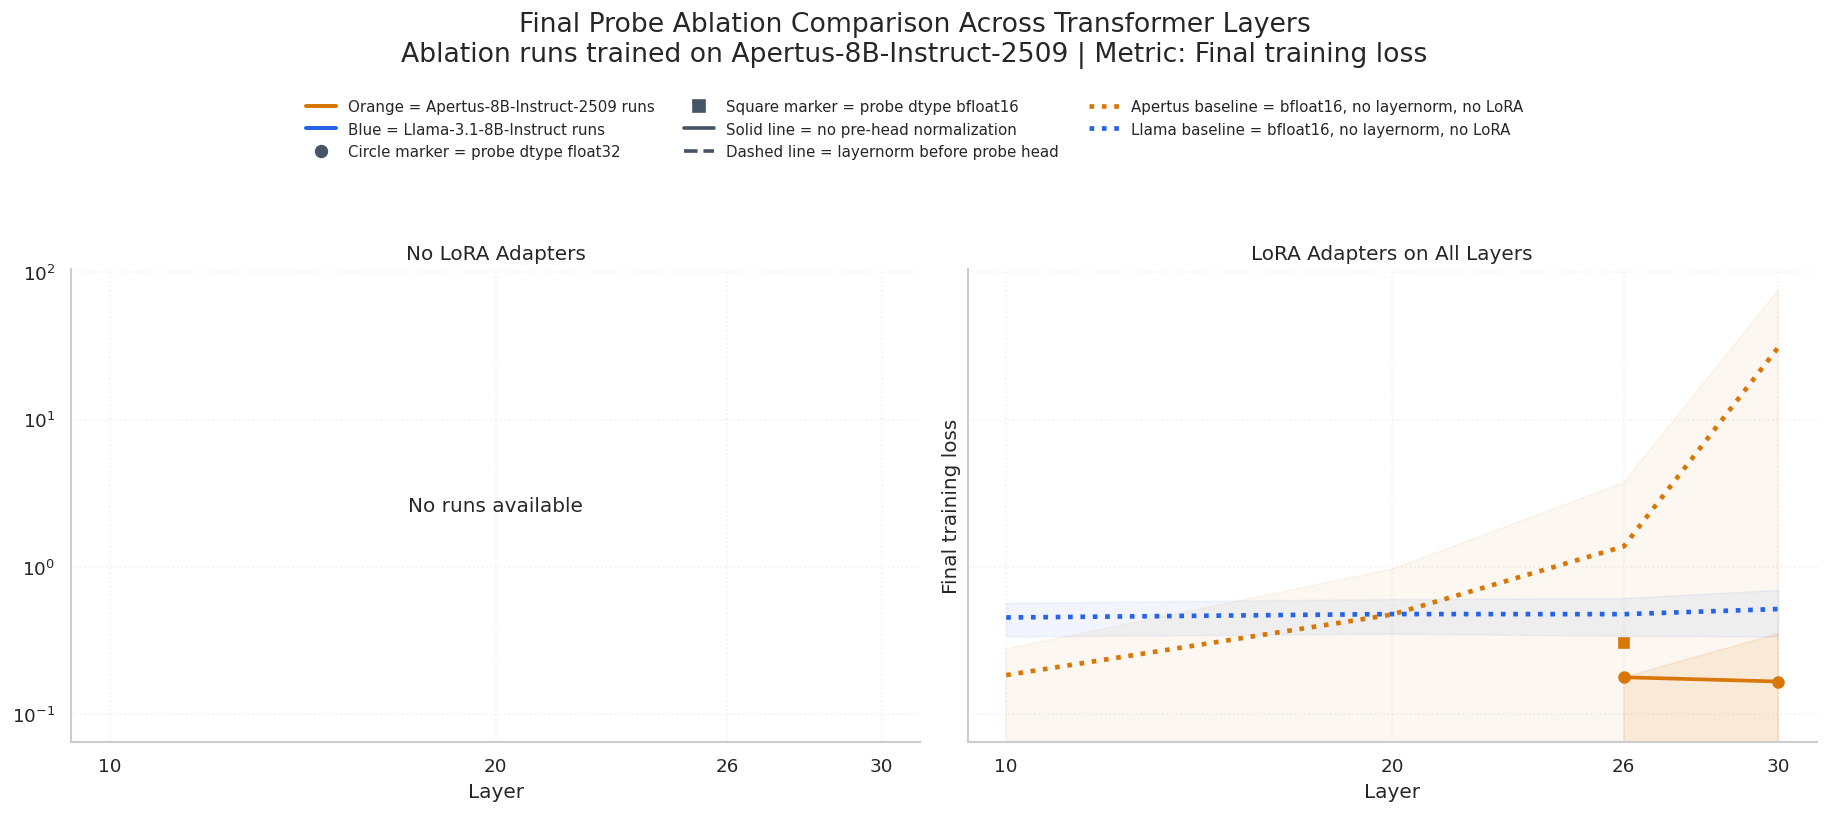

In [9]:
from matplotlib.lines import Line2D

METRIC_OPTIONS = {
    "r_at_0.1": {"kind": "metric", "metric": "recall_at_0.1_fpr", "label": "Recall at 0.1 FPR (R@0.1)"},
    "auc": {"kind": "metric", "metric": "auc", "label": "AUC"},
    "f1": {"kind": "metric", "metric": "f1", "label": "F1"},
    "final_loss": {"kind": "loss", "loss_key": "train/loss", "label": "Final training loss"},
}

COLOR_BY_MODEL = {"apertus": "#D97706", "llama": "#2563EB"}
LINESTYLE_BY_NORM = {"none": "-", "layernorm": "--"}
MARKER_BY_DTYPE = {"fp32": "o", "bf16": "s"}


def _variant_norm(variant: str) -> str:
    variant = str(variant)
    if variant.endswith("no_ln"):
        return "none"
    if variant.endswith("_ln"):
        return "layernorm"
    return "none"


def _variant_lora_group(variant: str) -> str:
    return "lora" if str(variant).startswith("lora_") else "no_lora"


def _build_legend_handles(include_baseline: bool):
    handles = [
        Line2D([0], [0], color=COLOR_BY_MODEL["apertus"], linewidth=2.4, label="Orange = Apertus-8B-Instruct-2509 runs"),
        Line2D([0], [0], color=COLOR_BY_MODEL["llama"], linewidth=2.4, label="Blue = Llama-3.1-8B-Instruct runs"),
        Line2D([0], [0], color="#475569", marker=MARKER_BY_DTYPE["fp32"], linewidth=0, markersize=7, label="Circle marker = probe dtype float32"),
        Line2D([0], [0], color="#475569", marker=MARKER_BY_DTYPE["bf16"], linewidth=0, markersize=7, label="Square marker = probe dtype bfloat16"),
        Line2D([0], [0], color="#475569", linestyle="-", linewidth=2.2, label="Solid line = no pre-head normalization"),
        Line2D([0], [0], color="#475569", linestyle="--", linewidth=2.2, label="Dashed line = layernorm before probe head"),
    ]
    if include_baseline:
        handles.extend([
            Line2D([0], [0], color=COLOR_BY_MODEL["apertus"], linestyle=":", linewidth=2.8, label="Apertus baseline = bfloat16, no layernorm, no LoRA"),
            Line2D([0], [0], color=COLOR_BY_MODEL["llama"], linestyle=":", linewidth=2.8, label="Llama baseline = bfloat16, no layernorm, no LoRA"),
        ])
    return handles


def plot_lora_vs_no_lora_by_layer(
    metric_option="r_at_0.1",
    *,
    train_model="apertus",
    test_model="apertus",
    metric_family="all",
    include_baseline=True,
    log_scale=False,
):
    if metric_option not in METRIC_OPTIONS:
        raise ValueError(f"Unknown metric_option={metric_option!r}. Use one of {list(METRIC_OPTIONS)}")

    spec = METRIC_OPTIONS[metric_option]
    train_display = MODEL_DISPLAY_NAMES.get(train_model, train_model)
    test_display = MODEL_DISPLAY_NAMES.get(test_model, test_model)

    if spec["kind"] == "metric":
        metric_name = spec["metric"]
        data = df_metrics_long[
            (df_metrics_long["run_kind"] == "final_ablation")
            & (df_metrics_long["train_model"] == train_model)
            & (df_metrics_long["metric"] == metric_name)
            & (df_metrics_long["metric_family"] == metric_family)
            & (df_metrics_long["test_model"] == test_model)
        ].copy()
    else:
        loss_key = spec["loss_key"]
        data = df_runs[
            (df_runs["run_kind"] == "final_ablation")
            & (df_runs["train_model"] == train_model)
        ][["variant", "probe_dtype_tag", "layer", loss_key]].copy()
        data = data.rename(columns={loss_key: "value"})
        data = data.dropna(subset=["value"])

    if data.empty:
        raise ValueError("No rows matched the requested filters.")

    data["norm_kind"] = data["variant"].map(_variant_norm)
    data["lora_group"] = data["variant"].map(_variant_lora_group)

    agg = (
        data.groupby(["lora_group", "variant", "probe_dtype_tag", "norm_kind", "layer"], observed=False)
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
        .reset_index()
    )
    agg["std"] = agg["std"].fillna(0.0)

    fig, axes = plt.subplots(1, 2, figsize=(15.4, 6.9), sharex=True, sharey=True)
    panel_order = [
        ("no_lora", "No LoRA Adapters"),
        ("lora", "LoRA Adapters on All Layers"),
    ]

    for ax, (panel_key, panel_title) in zip(axes, panel_order):
        panel = agg[agg["lora_group"] == panel_key]

        if panel.empty:
            ax.text(0.5, 0.5, "No runs available", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(panel_title)
            ax.set_xticks(LAYERS)
            ax.set_xlabel("Layer")
            ax.grid(True, alpha=0.25, linestyle=":")
            ax.spines[["top", "right"]].set_visible(False)
            if log_scale:
                ax.set_yscale("log")
            continue

        for (variant, dtype_tag, norm_kind), sub in panel.groupby(["variant", "probe_dtype_tag", "norm_kind"], observed=False):
            s = sub.set_index("layer").reindex(LAYERS).reset_index()
            y = s["mean"].to_numpy()
            e = s["std"].to_numpy()
            if pd.isna(y).all():
                continue

            ax.plot(
                LAYERS,
                y,
                color=COLOR_BY_MODEL[train_model],
                linestyle=LINESTYLE_BY_NORM.get(norm_kind, "-"),
                marker=MARKER_BY_DTYPE.get(dtype_tag, "o"),
                markersize=6.5,
                linewidth=2.2,
            )
            ax.fill_between(LAYERS, y - e, y + e, color=COLOR_BY_MODEL[train_model], alpha=0.10)

        if include_baseline:
            for baseline_train_model in TRAIN_MODELS:
                base = df_runs[
                    (df_runs["run_kind"] == "baseline")
                    & (df_runs["train_model"] == baseline_train_model)
                ].copy()
                if base.empty:
                    continue

                if spec["kind"] == "metric":
                    metric_col = f"train/longfact_test_{test_model}/{metric_family}_{spec['metric']}"
                    base = base[["layer", metric_col]].rename(columns={metric_col: "value"}).dropna(subset=["value"])
                else:
                    base = base[["layer", spec["loss_key"]]].rename(columns={spec['loss_key']: "value"}).dropna(subset=["value"])

                if base.empty:
                    continue

                base_agg = base.groupby("layer", observed=False).agg(mean=("value", "mean"), std=("value", "std")).reset_index()
                base_agg["std"] = base_agg["std"].fillna(0.0)
                b = base_agg.set_index("layer").reindex(LAYERS).reset_index()
                by = b["mean"].to_numpy()
                be = b["std"].to_numpy()
                ax.plot(LAYERS, by, color=COLOR_BY_MODEL[baseline_train_model], linestyle=":", linewidth=2.8)
                ax.fill_between(LAYERS, by - be, by + be, color=COLOR_BY_MODEL[baseline_train_model], alpha=0.06)

        ax.set_title(panel_title)
        ax.set_xticks(LAYERS)
        ax.set_xlabel("Layer")
        ax.set_ylabel(spec["label"])
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)
        if log_scale:
            ax.set_yscale("log")

    main_title = "Final Probe Ablation Comparison Across Transformer Layers"
    if spec["kind"] == "metric":
        subtitle = (
            f"Ablation runs trained on {train_display} | Evaluated on {test_display} | "
            f"Metric family: {metric_family} | Metric: {spec['label']}"
        )
    else:
        subtitle = f"Ablation runs trained on {train_display} | Metric: {spec['label']}"

    fig.suptitle(f"{main_title}\n{subtitle}", y=0.98, fontsize=16)
    legend_handles = _build_legend_handles(include_baseline=include_baseline)
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.89),
        ncol=3,
        frameon=False,
        fontsize=9,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    plt.show()


# Example calls
plot_lora_vs_no_lora_by_layer(metric_option="r_at_0.1", train_model="apertus", test_model="apertus", metric_family="all")
plot_lora_vs_no_lora_by_layer(metric_option="auc", train_model="llama", test_model="llama", metric_family="all")
plot_lora_vs_no_lora_by_layer(metric_option="f1", train_model="apertus", test_model="llama", metric_family="all")
plot_lora_vs_no_lora_by_layer(metric_option="final_loss", train_model="apertus", log_scale=True)

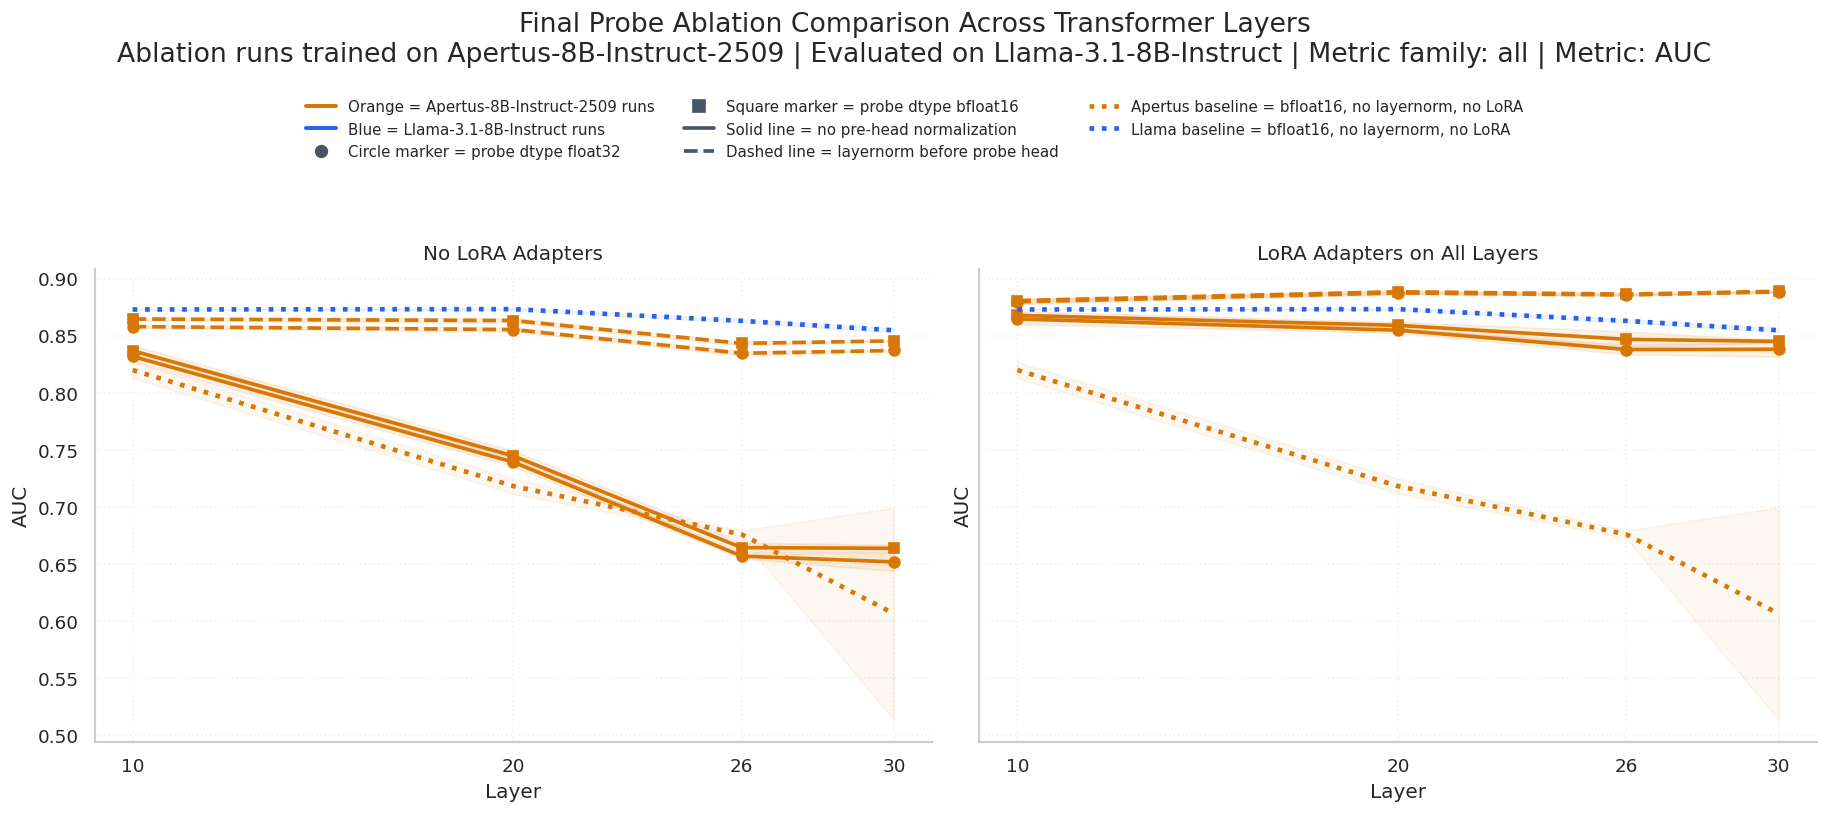

In [18]:
plot_lora_vs_no_lora_by_layer(metric_option="auc", train_model="apertus", test_model="llama", metric_family="all")


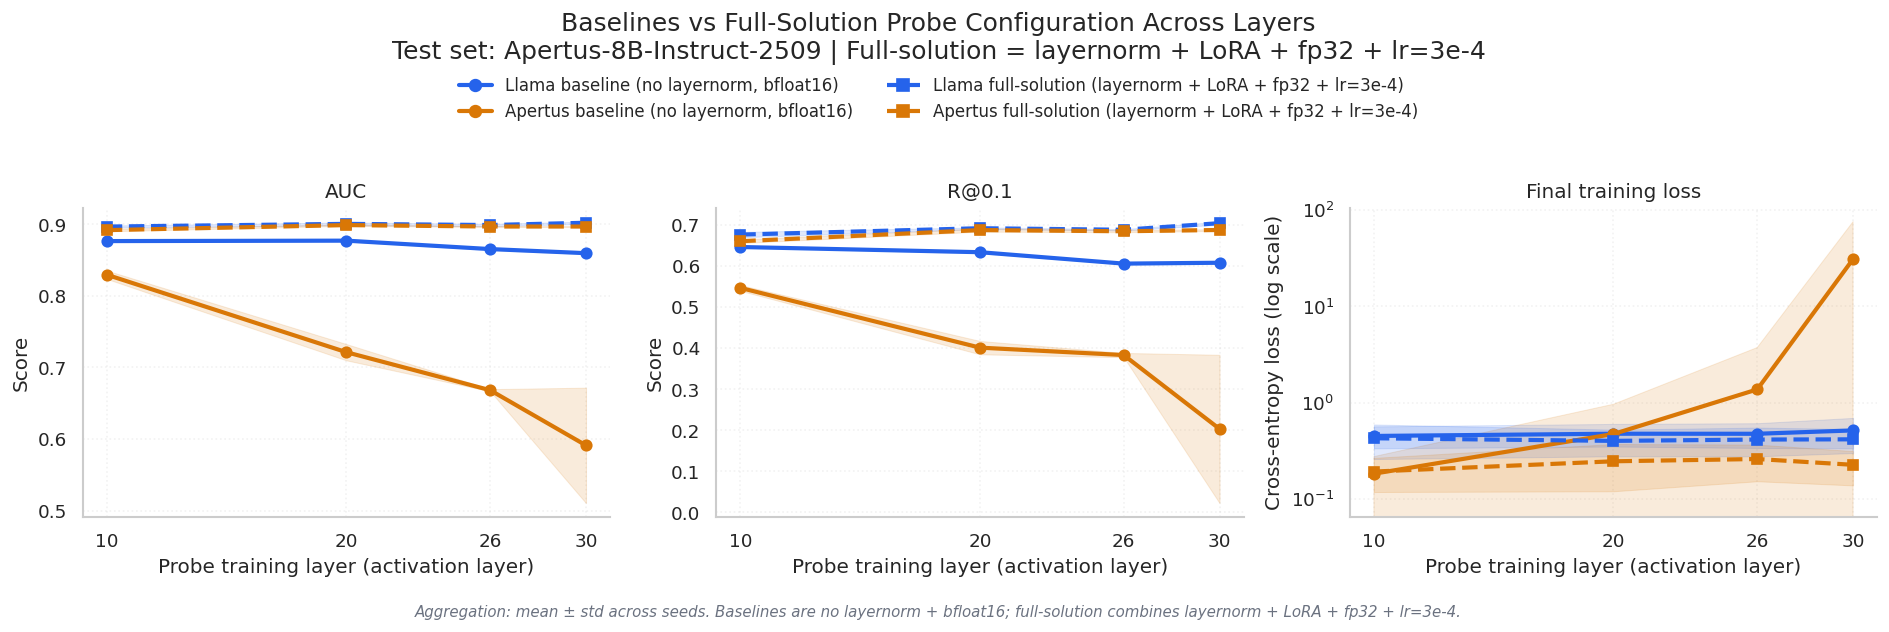

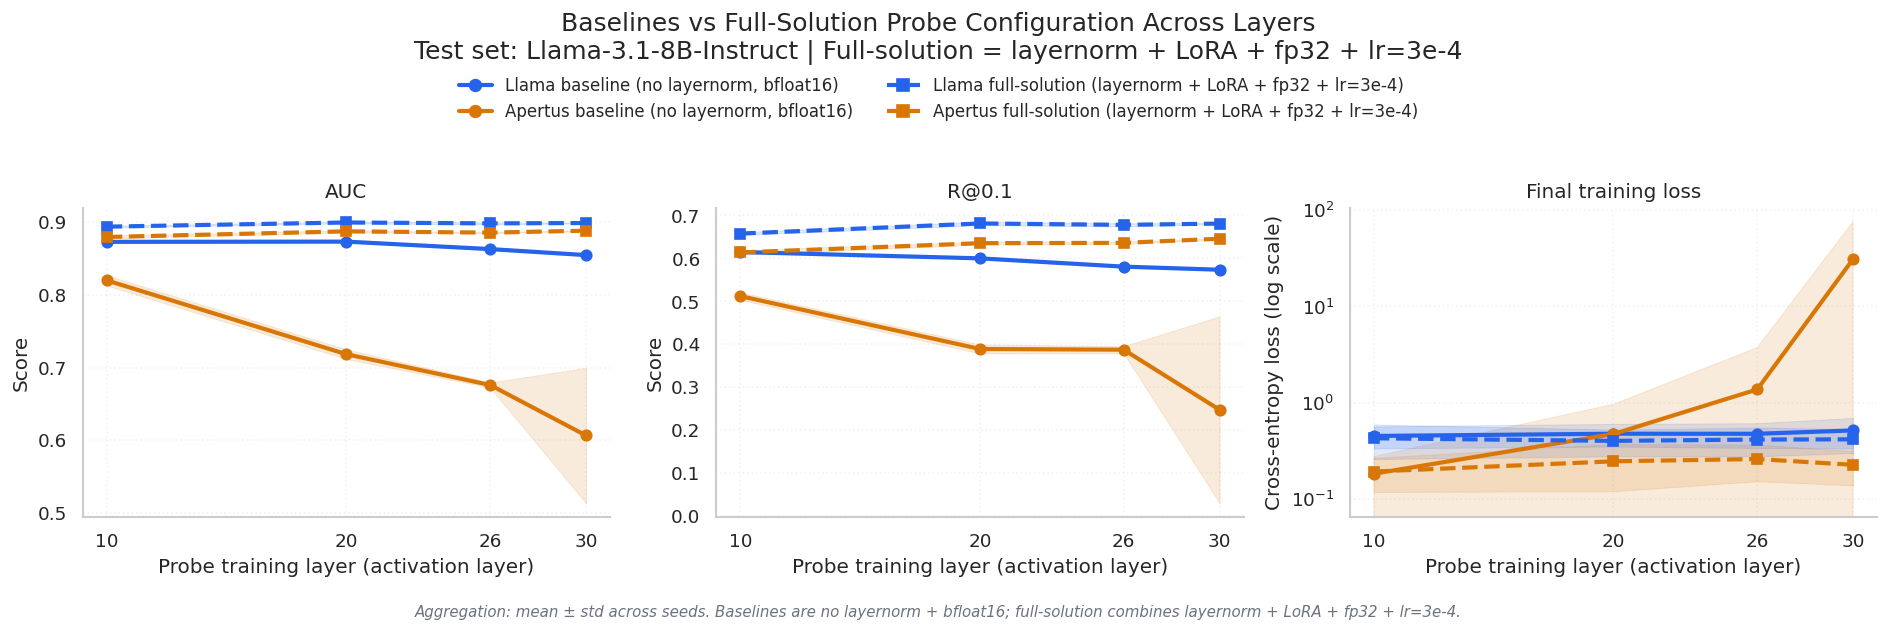

In [15]:
from matplotlib.lines import Line2D


def plot_baselines_vs_full_solution(
    df_metrics_long,
    df_runs,
    *,
    test_model="apertus",
    metric_family="all",
):
    model_display = {
        "apertus": "Apertus-8B-Instruct-2509",
        "llama": "Llama-3.1-8B-Instruct",
    }

    # Style semantics requested: Llama blue, Apertus orange; baseline solid, improvement dashed
    color_by_model = {
        "llama": "#2563EB",
        "apertus": "#D97706",
    }
    linestyle_by_group = {
        "baseline": "-",
        "full_solution": "--",
    }
    marker_by_group = {
        "baseline": "o",
        "full_solution": "s",
    }

    # "all solutions" = layernorm + fp32 + lora; lr=3e-4 assumed from experiment setup
    full_solution = df_metrics_long[
        (df_metrics_long["run_kind"] == "final_ablation")
        & (df_metrics_long["variant"] == "lora_ln")
        & (df_metrics_long["probe_dtype_tag"] == "fp32")
        & (df_metrics_long["metric_family"] == metric_family)
        & (df_metrics_long["test_model"] == test_model)
        & (df_metrics_long["metric"].isin(["auc", "recall_at_0.1_fpr"]))
    ][["metric", "train_model", "layer", "seed", "value"]].copy()
    full_solution["group"] = "full_solution"

    baselines = df_metrics_long[
        (df_metrics_long["run_kind"] == "baseline")
        & (df_metrics_long["metric_family"] == metric_family)
        & (df_metrics_long["test_model"] == test_model)
        & (df_metrics_long["metric"].isin(["auc", "recall_at_0.1_fpr"]))
        & (df_metrics_long["train_model"].isin(["apertus", "llama"]))
    ][["metric", "train_model", "layer", "seed", "value"]].copy()
    baselines["group"] = "baseline"

    metric_subset = pd.concat([baselines, full_solution], ignore_index=True)
    if metric_subset.empty:
        raise ValueError("No matching metric rows found for baselines/full-solution comparison.")

    agg_metrics = (
        metric_subset.groupby(["metric", "train_model", "group", "layer"], observed=False)
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
        .reset_index()
    )
    agg_metrics["std"] = agg_metrics["std"].fillna(0.0)

    # Final training loss panel
    loss_full_solution = df_runs[
        (df_runs["run_kind"] == "final_ablation")
        & (df_runs["variant"] == "lora_ln")
        & (df_runs["probe_dtype_tag"] == "fp32")
    ][["train_model", "layer", "seed", "train/loss"]].copy()
    loss_full_solution = loss_full_solution.rename(columns={"train/loss": "value"})
    loss_full_solution["group"] = "full_solution"

    loss_baselines = df_runs[
        (df_runs["run_kind"] == "baseline")
        & (df_runs["train_model"].isin(["apertus", "llama"]))
    ][["train_model", "layer", "seed", "train/loss"]].copy()
    loss_baselines = loss_baselines.rename(columns={"train/loss": "value"})
    loss_baselines["group"] = "baseline"

    loss_subset = pd.concat([loss_baselines, loss_full_solution], ignore_index=True)
    loss_subset = loss_subset.dropna(subset=["value"])
    if loss_subset.empty:
        raise ValueError("No final loss values available for baselines/full-solution comparison.")

    agg_loss = (
        loss_subset.groupby(["train_model", "group", "layer"], observed=False)
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
        .reset_index()
    )
    agg_loss["std"] = agg_loss["std"].fillna(0.0)

    fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.2), sharex=True)
    panel_specs = [
        ("auc", "AUC", "Score"),
        ("recall_at_0.1_fpr", "R@0.1", "Score"),
        ("final_loss", "Final training loss", "Cross-entropy loss (log scale)"),
    ]

    plot_order = [
        ("llama", "baseline"),
        ("apertus", "baseline"),
        ("llama", "full_solution"),
        ("apertus", "full_solution"),
    ]

    for ax, (metric_key, panel_title, y_label) in zip(axes, panel_specs):
        for train_model, group in plot_order:
            if metric_key == "final_loss":
                s = (
                    agg_loss[
                        (agg_loss["train_model"] == train_model)
                        & (agg_loss["group"] == group)
                    ]
                    .set_index("layer")
                    .reindex(LAYERS)
                    .reset_index()
                )
            else:
                s = (
                    agg_metrics[
                        (agg_metrics["metric"] == metric_key)
                        & (agg_metrics["train_model"] == train_model)
                        & (agg_metrics["group"] == group)
                    ]
                    .set_index("layer")
                    .reindex(LAYERS)
                    .reset_index()
                )

            y = s["mean"].to_numpy()
            e = s["std"].to_numpy()
            if pd.isna(y).all():
                continue

            ax.plot(
                LAYERS,
                y,
                color=color_by_model[train_model],
                linestyle=linestyle_by_group[group],
                marker=marker_by_group[group],
                markersize=6.3,
                linewidth=2.5,
            )
            ax.fill_between(
                LAYERS,
                y - e,
                y + e,
                color=color_by_model[train_model],
                alpha=0.14,
                edgecolor=color_by_model[train_model],
                linewidth=0.6,
            )

        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel("Probe training layer (activation layer)")
        ax.set_ylabel(y_label)
        ax.set_xticks(LAYERS)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)
        if metric_key == "final_loss":
            ax.set_yscale("log")

    test_display = model_display.get(test_model, test_model)
    fig.suptitle(
        "Baselines vs Full-Solution Probe Configuration Across Layers\n"
        f"Test set: {test_display} | Full-solution = layernorm + LoRA + fp32 + lr=3e-4",
        y=0.98,
        fontsize=15,
    )

    legend_handles = [
        Line2D([0], [0], color=color_by_model["llama"], linestyle="-", marker="o", linewidth=2.5, markersize=7,
               label="Llama baseline (no layernorm, bfloat16)"),
        Line2D([0], [0], color=color_by_model["apertus"], linestyle="-", marker="o", linewidth=2.5, markersize=7,
               label="Apertus baseline (no layernorm, bfloat16)"),
        Line2D([0], [0], color=color_by_model["llama"], linestyle="--", marker="s", linewidth=2.5, markersize=7,
               label="Llama full-solution (layernorm + LoRA + fp32 + lr=3e-4)"),
        Line2D([0], [0], color=color_by_model["apertus"], linestyle="--", marker="s", linewidth=2.5, markersize=7,
               label="Apertus full-solution (layernorm + LoRA + fp32 + lr=3e-4)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.90),
        fontsize=10,
    )

    fig.text(
        0.5,
        0.01,
        "Aggregation: mean ± std across seeds. Baselines are no layernorm + bfloat16; full-solution combines layernorm + LoRA + fp32 + lr=3e-4.",
        ha="center",
        fontsize=9,
        color="#6B7280",
        style="italic",
    )

    fig.tight_layout(rect=[0, 0.04, 1, 0.86])
    plt.show()


plot_baselines_vs_full_solution(df_metrics_long, df_runs, test_model="apertus", metric_family="all")
plot_baselines_vs_full_solution(df_metrics_long, df_runs, test_model="llama", metric_family="all")

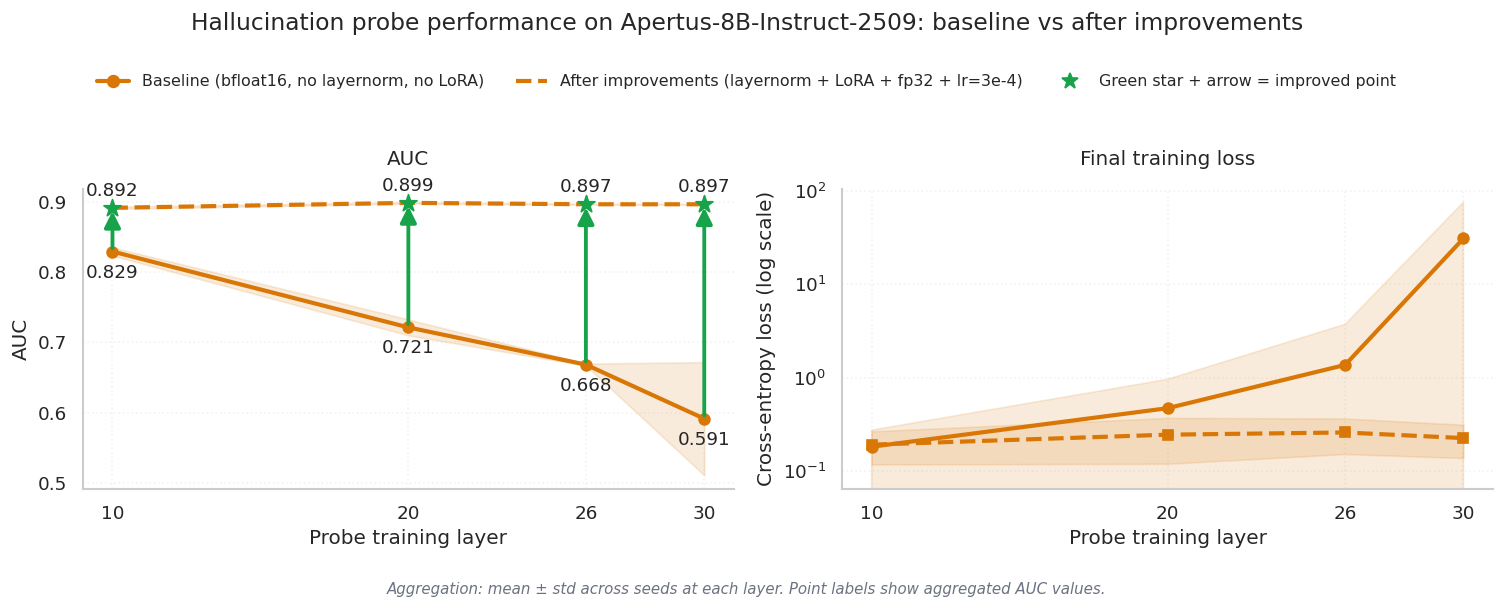

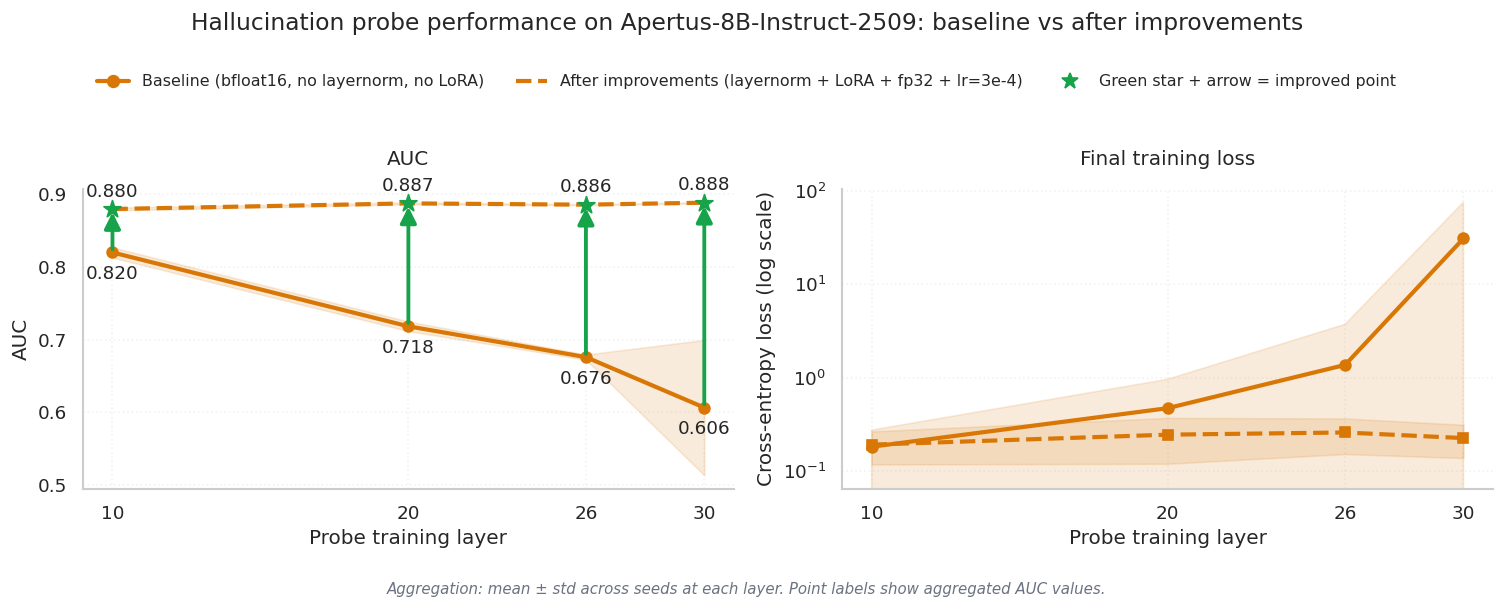

In [23]:
def plot_apertus_baseline_vs_full_solution_with_values(
    df_metrics_long,
    df_runs,
    *,
    test_model="apertus",
    metric_family="all",
):
    # test_model is kept as a filter argument only
    color_apertus = "#D97706"
    linestyle_by_group = {"baseline": "-", "full_solution": "--"}
    marker_by_group = {"baseline": "o", "full_solution": "s"}

    # Full solution definition used in this notebook
    full_solution = df_metrics_long[
        (df_metrics_long["run_kind"] == "final_ablation")
        & (df_metrics_long["train_model"] == "apertus")
        & (df_metrics_long["variant"] == "lora_ln")
        & (df_metrics_long["probe_dtype_tag"] == "fp32")
        & (df_metrics_long["metric_family"] == metric_family)
        & (df_metrics_long["test_model"] == test_model)
        & (df_metrics_long["metric"] == "auc")
    ][["metric", "layer", "seed", "value"]].copy()
    full_solution["group"] = "full_solution"

    baseline = df_metrics_long[
        (df_metrics_long["run_kind"] == "baseline")
        & (df_metrics_long["train_model"] == "apertus")
        & (df_metrics_long["metric_family"] == metric_family)
        & (df_metrics_long["test_model"] == test_model)
        & (df_metrics_long["metric"] == "auc")
    ][["metric", "layer", "seed", "value"]].copy()
    baseline["group"] = "baseline"

    metric_subset = pd.concat([baseline, full_solution], ignore_index=True)
    if metric_subset.empty:
        raise ValueError("No matching Apertus AUC rows found for baseline/full-solution comparison.")

    agg_auc = (
        metric_subset.groupby(["group", "layer"], observed=False)
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
        .reset_index()
    )
    agg_auc["std"] = agg_auc["std"].fillna(0.0)

    # Final training loss (Apertus only)
    loss_full = df_runs[
        (df_runs["run_kind"] == "final_ablation")
        & (df_runs["train_model"] == "apertus")
        & (df_runs["variant"] == "lora_ln")
        & (df_runs["probe_dtype_tag"] == "fp32")
    ][["layer", "seed", "train/loss"]].rename(columns={"train/loss": "value"})
    loss_full["group"] = "full_solution"

    loss_base = df_runs[
        (df_runs["run_kind"] == "baseline")
        & (df_runs["train_model"] == "apertus")
    ][["layer", "seed", "train/loss"]].rename(columns={"train/loss": "value"})
    loss_base["group"] = "baseline"

    loss_subset = pd.concat([loss_base, loss_full], ignore_index=True).dropna(subset=["value"])
    if loss_subset.empty:
        raise ValueError("No Apertus final-loss rows found for baseline/full-solution comparison.")

    agg_loss = (
        loss_subset.groupby(["group", "layer"], observed=False)
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "count"))
        .reset_index()
    )
    agg_loss["std"] = agg_loss["std"].fillna(0.0)

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0), sharex=True)

    # ---------- Panel 1: AUC ----------
    ax_auc = axes[0]
    for group in ["baseline", "full_solution"]:
        s = agg_auc[agg_auc["group"] == group].set_index("layer").reindex(LAYERS).reset_index()
        y = s["mean"].to_numpy()
        e = s["std"].to_numpy()
        if pd.isna(y).all():
            continue

        # AUC panel: keep marker only for baseline (requested)
        plot_kwargs = dict(
            color=color_apertus,
            linestyle=linestyle_by_group[group],
            linewidth=2.5,
        )
        if group == "baseline":
            plot_kwargs.update(marker=marker_by_group[group], markersize=6.5)

        ax_auc.plot(LAYERS, y, **plot_kwargs)
        ax_auc.fill_between(LAYERS, y - e, y + e, color=color_apertus, alpha=0.14)

        # Metric values on curve (larger font + more padding)
        for x, yv in zip(LAYERS, y):
            if pd.notna(yv):
                dy = 0.024 if group == "full_solution" else -0.030
                ax_auc.text(x, yv + dy, f"{yv:.3f}", ha="center", va="center", fontsize=11)

    # Visual markers for improvement (AUC panel only)
    auc_base = agg_auc[agg_auc["group"] == "baseline"].set_index("layer").reindex(LAYERS)["mean"]
    auc_full = agg_auc[agg_auc["group"] == "full_solution"].set_index("layer").reindex(LAYERS)["mean"]
    for x in LAYERS:
        b = auc_base.loc[x] if x in auc_base.index else float("nan")
        f = auc_full.loc[x] if x in auc_full.index else float("nan")
        if pd.notna(b) and pd.notna(f) and f > b:
            ax_auc.annotate(
                "",
                xy=(x, f),
                xytext=(x, b),
                arrowprops=dict(arrowstyle="-|>", color="#16A34A", lw=2.3, mutation_scale=20),
            )
            ax_auc.scatter([x], [f], marker="*", s=115, color="#16A34A", zorder=5)

    ax_auc.set_title("AUC", fontsize=12, pad=14)
    ax_auc.set_xlabel("Probe training layer")
    ax_auc.set_ylabel("AUC")
    ax_auc.set_xticks(LAYERS)
    ax_auc.grid(True, alpha=0.25, linestyle=":")
    ax_auc.spines[["top", "right"]].set_visible(False)

    # ---------- Panel 2: Final training loss ----------
    ax_loss = axes[1]
    for group in ["baseline", "full_solution"]:
        s = agg_loss[agg_loss["group"] == group].set_index("layer").reindex(LAYERS).reset_index()
        y = s["mean"].to_numpy()
        e = s["std"].to_numpy()
        if pd.isna(y).all():
            continue

        ax_loss.plot(
            LAYERS, y,
            color=color_apertus,
            linestyle=linestyle_by_group[group],
            marker=marker_by_group[group],
            markersize=6.5,
            linewidth=2.5,
        )
        ax_loss.fill_between(LAYERS, y - e, y + e, color=color_apertus, alpha=0.14)

    # No arrows and no point captions in loss panel (as requested)
    ax_loss.set_title("Final training loss", fontsize=12, pad=14)
    ax_loss.set_xlabel("Probe training layer")
    ax_loss.set_ylabel("Cross-entropy loss (log scale)")
    ax_loss.set_xticks(LAYERS)
    ax_loss.set_yscale("log")
    ax_loss.grid(True, alpha=0.25, linestyle=":")
    ax_loss.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        "Hallucination probe performance on Apertus-8B-Instruct-2509: baseline vs after improvements",
        y=0.98,
        fontsize=14,
    )

    legend_handles = [
        Line2D([0], [0], color=color_apertus, linestyle="-", marker="o", linewidth=2.5, markersize=7,
               label="Baseline (bfloat16, no layernorm, no LoRA)"),
        Line2D([0], [0], color=color_apertus, linestyle="--", linewidth=2.5,
               label="After improvements (layernorm + LoRA + fp32 + lr=3e-4)"),
        Line2D([0], [0], color="#16A34A", marker="*", linewidth=0, markersize=10,
               label="Green star + arrow = improved point"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.90),
        fontsize=9.5,
    )

    fig.text(
        0.5, 0.01,
        "Aggregation: mean ± std across seeds at each layer. Point labels show aggregated AUC values.",
        ha="center",
        fontsize=9,
        color="#6B7280",
        style="italic",
    )

    fig.tight_layout(rect=[0, 0.05, 1, 0.86])
    plt.show()


plot_apertus_baseline_vs_full_solution_with_values(
    df_metrics_long,
    df_runs,
    test_model="apertus",
    metric_family="all",
)
plot_apertus_baseline_vs_full_solution_with_values(
    df_metrics_long,
    df_runs,
    test_model="llama",
    metric_family="all",
)

In [16]:
# Quantitative summary: baseline vs full-solution improvements
# full-solution = lora_ln + fp32
# baseline = *_no_lora_long_form_* (bfloat16, no layernorm)

metric_family = "all"
full_variant = "lora_ln"
full_dtype = "fp32"

# ----- Performance deltas (AUC, R@0.1)
full_perf = df_metrics_long[
    (df_metrics_long["run_kind"] == "final_ablation")
    & (df_metrics_long["variant"] == full_variant)
    & (df_metrics_long["probe_dtype_tag"] == full_dtype)
    & (df_metrics_long["metric_family"] == metric_family)
    & (df_metrics_long["metric"].isin(["auc", "recall_at_0.1_fpr"]))
][["train_model", "test_model", "metric", "layer", "seed", "value"]].copy()

base_perf = df_metrics_long[
    (df_metrics_long["run_kind"] == "baseline")
    & (df_metrics_long["metric_family"] == metric_family)
    & (df_metrics_long["metric"].isin(["auc", "recall_at_0.1_fpr"]))
][["train_model", "test_model", "metric", "layer", "seed", "value"]].copy()

paired_perf = base_perf.merge(
    full_perf,
    on=["train_model", "test_model", "metric", "layer", "seed"],
    suffixes=("_baseline", "_full"),
)
paired_perf["delta_full_minus_baseline"] = paired_perf["value_full"] - paired_perf["value_baseline"]

perf_summary = (
    paired_perf.groupby(["train_model", "test_model", "metric"], observed=False)
    .agg(
        mean_baseline=("value_baseline", "mean"),
        mean_full=("value_full", "mean"),
        mean_delta=("delta_full_minus_baseline", "mean"),
        median_delta=("delta_full_minus_baseline", "median"),
        min_delta=("delta_full_minus_baseline", "min"),
        max_delta=("delta_full_minus_baseline", "max"),
        n=("delta_full_minus_baseline", "count"),
    )
    .reset_index()
    .sort_values(["test_model", "train_model", "metric"])
)

# ----- Stability deltas from final loss
full_loss = df_runs[
    (df_runs["run_kind"] == "final_ablation")
    & (df_runs["variant"] == full_variant)
    & (df_runs["probe_dtype_tag"] == full_dtype)
][["train_model", "layer", "seed", "train/loss"]].rename(columns={"train/loss": "loss_full"})

base_loss = df_runs[
    (df_runs["run_kind"] == "baseline")
][["train_model", "layer", "seed", "train/loss"]].rename(columns={"train/loss": "loss_baseline"})

paired_loss = base_loss.merge(full_loss, on=["train_model", "layer", "seed"], how="inner")
paired_loss = paired_loss.dropna(subset=["loss_baseline", "loss_full"]) 
paired_loss["loss_ratio_full_over_baseline"] = paired_loss["loss_full"] / paired_loss["loss_baseline"]
paired_loss["log10_ratio"] = (paired_loss["loss_ratio_full_over_baseline"]).map(lambda x: float("nan") if x <= 0 else __import__("math").log10(x))

stab_summary = (
    paired_loss.groupby(["train_model"], observed=False)
    .agg(
        mean_loss_baseline=("loss_baseline", "mean"),
        mean_loss_full=("loss_full", "mean"),
        mean_loss_ratio=("loss_ratio_full_over_baseline", "mean"),
        median_loss_ratio=("loss_ratio_full_over_baseline", "median"),
        max_loss_ratio=("loss_ratio_full_over_baseline", "max"),
        min_loss_ratio=("loss_ratio_full_over_baseline", "min"),
        n=("loss_ratio_full_over_baseline", "count"),
    )
    .reset_index()
    .sort_values(["train_model"])
)

# Variability across seeds by layer (std across seeds), then average over layers
base_seed_std = (
    base_loss.groupby(["train_model", "layer"], observed=False)["loss_baseline"]
    .std()
    .reset_index(name="seed_std_baseline")
)
full_seed_std = (
    full_loss.groupby(["train_model", "layer"], observed=False)["loss_full"]
    .std()
    .reset_index(name="seed_std_full")
)
seed_std = base_seed_std.merge(full_seed_std, on=["train_model", "layer"], how="inner")
seed_std["std_ratio_full_over_baseline"] = seed_std["seed_std_full"] / seed_std["seed_std_baseline"]
seed_std_summary = (
    seed_std.groupby("train_model", observed=False)
    .agg(
        mean_seed_std_baseline=("seed_std_baseline", "mean"),
        mean_seed_std_full=("seed_std_full", "mean"),
        mean_std_ratio=("std_ratio_full_over_baseline", "mean"),
    )
    .reset_index()
)

print("=== PERFORMANCE: full-solution - baseline ===")
display(perf_summary)

print("=== STABILITY (LOSS LEVEL): full / baseline ===")
display(stab_summary)

print("=== STABILITY (SEED VARIABILITY): std(full) / std(baseline) ===")
display(seed_std_summary)

=== PERFORMANCE: full-solution - baseline ===


,train_model,test_model,metric,mean_baseline,mean_full,mean_delta,median_delta,min_delta,max_delta,n
0,apertus,apertus,auc,0.702550,0.896051,0.193502,0.207454,0.057996,0.397121,12
1,apertus,apertus,recall_at_0.1_fpr,0.383668,0.680226,0.296558,0.297340,0.108582,0.687083,12
4,llama,apertus,auc,0.869628,0.899574,0.029946,0.028108,0.018899,0.045084,12
5,llama,apertus,recall_at_0.1_fpr,0.623566,0.690446,0.066880,0.070019,0.023105,0.102793,12
2,apertus,llama,auc,0.705135,0.885232,0.180098,0.189490,0.056094,0.388010,12
3,apertus,llama,recall_at_0.1_fpr,0.383868,0.632657,0.248788,0.243858,0.093854,0.644574,12
6,llama,llama,auc,0.865962,0.897645,0.031684,0.030002,0.019563,0.045876,12
7,llama,llama,recall_at_0.1_fpr,0.592176,0.674440,0.082264,0.088250,0.040626,0.109824,12


=== STABILITY (LOSS LEVEL): full / baseline ===


,train_model,mean_loss_baseline,mean_loss_full,mean_loss_ratio,median_loss_ratio,max_loss_ratio,min_loss_ratio,n
0,apertus,8.235992,0.231546,231.747502,1.031731,1774.903620,0.001550,12
1,llama,0.479737,0.414899,0.862673,0.866939,1.063733,0.756634,12


=== STABILITY (SEED VARIABILITY): std(full) / std(baseline) ===


,train_model,mean_seed_std_baseline,mean_seed_std_full,mean_std_ratio
0,apertus,11.887233,0.098982,0.277739
1,llama,0.139566,0.136042,1.018554


In [17]:
from IPython.display import Markdown, display

# Drop-in report table (focused on Apertus-trained -> Apertus-tested)
row_auc = perf_summary[
    (perf_summary["train_model"] == "apertus")
    & (perf_summary["test_model"] == "apertus")
    & (perf_summary["metric"] == "auc")
].iloc[0]

row_r01 = perf_summary[
    (perf_summary["train_model"] == "apertus")
    & (perf_summary["test_model"] == "apertus")
    & (perf_summary["metric"] == "recall_at_0.1_fpr")
].iloc[0]

row_stab_ap = stab_summary[stab_summary["train_model"] == "apertus"].iloc[0]
row_stab_ll = stab_summary[stab_summary["train_model"] == "llama"].iloc[0]
row_seed_ap = seed_std_summary[seed_std_summary["train_model"] == "apertus"].iloc[0]

ap_loss_reduction_pct = 100.0 * (1.0 - (row_stab_ap["mean_loss_full"] / row_stab_ap["mean_loss_baseline"]))

report_md = f"""
## Final improvement summary (drop-in)

| Probe model (train) | Evaluation set | Metric | Baseline mean | Full-solution mean | Absolute improvement |
|---|---|---|---:|---:|---:|
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | AUC | {row_auc['mean_baseline']:.4f} | {row_auc['mean_full']:.4f} | +{row_auc['mean_delta']:.4f} |
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | R@0.1 | {row_r01['mean_baseline']:.4f} | {row_r01['mean_full']:.4f} | +{row_r01['mean_delta']:.4f} |

### Stability summary (Apertus probe)

| Stability indicator | Baseline | Full-solution | Change |
|---|---:|---:|---:|
| Mean final training loss | {row_stab_ap['mean_loss_baseline']:.3f} | {row_stab_ap['mean_loss_full']:.3f} | {ap_loss_reduction_pct:.1f}% lower |
| Seed-level loss std (avg over layers) | {row_seed_ap['mean_seed_std_baseline']:.3f} | {row_seed_ap['mean_seed_std_full']:.3f} | {(1.0-row_seed_ap['mean_std_ratio'])*100:.1f}% lower |

Additional context: baseline Llama probe mean final loss = {row_stab_ll['mean_loss_baseline']:.3f}.

Narrative-ready sentence:
The final solution improved Apertus-8B-Instruct-2509 probe performance on Apertus-8B-Instruct-2509 from AUC {row_auc['mean_baseline']:.4f} to {row_auc['mean_full']:.4f} (+{row_auc['mean_delta']:.4f}) and R@0.1 from {row_r01['mean_baseline']:.4f} to {row_r01['mean_full']:.4f} (+{row_r01['mean_delta']:.4f}), while reducing mean final training loss from {row_stab_ap['mean_loss_baseline']:.3f} to {row_stab_ap['mean_loss_full']:.3f} ({ap_loss_reduction_pct:.1f}% lower) and reducing seed-level loss variability from {row_seed_ap['mean_seed_std_baseline']:.3f} to {row_seed_ap['mean_seed_std_full']:.3f}.
"""

display(Markdown(report_md))
print(report_md)


## Final improvement summary (drop-in)

| Probe model (train) | Evaluation set | Metric | Baseline mean | Full-solution mean | Absolute improvement |
|---|---|---|---:|---:|---:|
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | AUC | 0.7025 | 0.8961 | +0.1935 |
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | R@0.1 | 0.3837 | 0.6802 | +0.2966 |

### Stability summary (Apertus probe)

| Stability indicator | Baseline | Full-solution | Change |
|---|---:|---:|---:|
| Mean final training loss | 8.236 | 0.232 | 97.2% lower |
| Seed-level loss std (avg over layers) | 11.887 | 0.099 | 72.2% lower |

Additional context: baseline Llama probe mean final loss = 0.480.

Narrative-ready sentence:
The final solution improved Apertus-8B-Instruct-2509 probe performance on Apertus-8B-Instruct-2509 from AUC 0.7025 to 0.8961 (+0.1935) and R@0.1 from 0.3837 to 0.6802 (+0.2966), while reducing mean final training loss from 8.236 to 0.232 (97.2% lower) and reducing seed-level loss variability from 11.887 to 0.099.



## Final improvement summary (drop-in)

| Probe model (train) | Evaluation set | Metric | Baseline mean | Full-solution mean | Absolute improvement |
|---|---|---|---:|---:|---:|
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | AUC | 0.7025 | 0.8961 | +0.1935 |
| Apertus-8B-Instruct-2509 | Apertus-8B-Instruct-2509 | R@0.1 | 0.3837 | 0.6802 | +0.2966 |

### Stability summary (Apertus probe)

| Stability indicator | Baseline | Full-solution | Change |
|---|---:|---:|---:|
| Mean final training loss | 8.236 | 0.232 | 97.2% lower |
| Seed-level loss std (avg over layers) | 11.887 | 0.099 | 72.2% lower |

Additional context: baseline Llama probe mean final loss = 0.480.

Narrative-ready sentence:
The final solution improved Apertus-8B-Instruct-2509 probe performance on Apertus-8B-Instruct-2509 from AUC 0.7025 to 0.8961 (+0.1935) and R@0.1 from 0.3837 to 0.6802 (+0.2966), while reducing mean final training loss from 8.236 to 0.232 (97.2% lower) and reducing seed-level loss variabilit